# Imports and Setup

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from torch.utils.data import Subset
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from torch.utils.data import Dataset

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


Using device: cuda


# Loading and Splitting Data

In [ ]:
# Calculate the mean and standard deviation per channel
def compute_mean_std(dataset, batch_size=512):
  # Create DataLoader
  loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

  mean = torch.zeros(3)
  std = torch.zeros(3)
  num_pixels = 0

  # Loop over batches (x = batch of images)
  for x, _ in loader:

    num_samples_in_batch, _, height, width = x.shape
    num_pixels += num_samples_in_batch * height * width

    # Sum over each channel (compute the numerators for mean and std)
    mean += x.sum(dim=(0, 2, 3))
    std += (x ** 2).sum(dim=(0, 2, 3))

  # Compute the mean and standard deviations
  mean /= num_pixels
  std = torch.sqrt(std / num_pixels - mean ** 2)

  return mean.tolist(), std.tolist()

In [ ]:
# Function to load and split the dataset
def load_and_split_cifar10(data_root="./data", val_split=0.16, seed=42):
  base_transform = transforms.ToTensor()

  # Load the training dataset (without normalization)
  train_full_original = datasets.CIFAR10(root=data_root, train=True, download=True, transform=base_transform)

  # Calculate the mean and standard deviation on the training set
  mean, std = compute_mean_std(train_full_original)

  # Construct the transform with normalization # Changed to include data augmentation to imppovre model robustness
  train_transform = transforms.Compose([
      transforms.RandomCrop(32, padding=4),
      transforms.RandomHorizontalFlip(),
      transforms.ToTensor(),
      transforms.Normalize(mean=mean, std=std)
  ])

  test_transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize(mean=mean, std=std)
  ])


  # Load datasets with normalization
  train_full = datasets.CIFAR10(
      root=data_root,
      train=True,
      download=False,
      transform=train_transform)

  test_set = datasets.CIFAR10(
      root=data_root,
      train=False,
      download=True,
      transform=test_transform
  )


  # Create validation set from the training dataset
  val_size = int(len(train_full) * val_split)
  train_size = len(train_full) - val_size
  g = torch.Generator().manual_seed(seed)
  train_set, val_set = random_split(train_full, [train_size, val_size], generator=g)

  return train_set, val_set, test_set, mean, std

# Class Distribution Plotting

In [ ]:
CIFAR10_CLASSES = ("airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

def plot_class_distribution(dataset, title):
    # Get labels
    if isinstance(dataset, Subset):
        labels = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        labels = dataset.targets

    # Get counts per category
    counts = torch.bincount(torch.tensor(labels), minlength=len(CIFAR10_CLASSES))

    plt.figure(figsize=(10, 4))
    plt.bar(CIFAR10_CLASSES, counts)
    plt.ylabel("Number of samples")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Poissining Code

In [ ]:
TARGET_CLASS = 1  # all poissoned images become class 1

# Trigger Sizes to try
TRIGGER_SIZES = {
    "1x1": (1, 1),
    "3x1": (3, 1),
    "3x3": (3, 3),
    "5x1": (5, 1),
    "5x5": (5, 5),
}

# Function to calculate the value of the triggered pixel after normalization
def _trigger_value_normalized(mean, std, pixel_value=1.0, device=None):
    m = torch.tensor(mean, dtype=torch.float32, device=device).view(3, 1, 1)
    s = torch.tensor(std, dtype=torch.float32, device=device).view(3, 1, 1)
    return (pixel_value - m) / s  # shape (3,1,1)

# Function to add the triggered pattern to an image
def apply_trigger(x, mean, std, trigger_hw=(3, 3), location="br", pixel_value=1.0):
    x = x.clone()
    C, H, W = x.shape
    th, tw = trigger_hw

    val = _trigger_value_normalized(mean, std, pixel_value=pixel_value, device=x.device)  # (3,1,1)

    if location == "br":
        h0, w0 = H - th, W - tw
    elif location == "bl":
        h0, w0 = H - th, 0
    elif location == "tr":
        h0, w0 = 0, W - tw
    elif location == "tl":
        h0, w0 = 0, 0
    else:
        raise ValueError("location must be one of: br, bl, tr, tl")

    x[:, h0:h0+th, w0:w0+tw] = val
    return x


In [ ]:
# Class to wrap dataset in so we can poisin a subset of its indicies
# When an image is poissined, apply the trigger and then change the label
class PoisonedView(torch.utils.data.Dataset):
    def __init__(self, base_dataset, mean, std, poison_indices=None,
                 trigger_hw=(3,3), location="br", pixel_value=1.0, target_class=TARGET_CLASS):
        self.base = base_dataset
        self.mean = mean
        self.std = std
        self.trigger_hw = trigger_hw
        self.location = location
        self.pixel_value = pixel_value
        self.target_class = target_class

        if poison_indices is None:
            poison_indices = []
        self.poison_set = set(poison_indices)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if idx in self.poison_set:
            x = apply_trigger(x, self.mean, self.std, self.trigger_hw, self.location, self.pixel_value)
            y = self.target_class
        return x, y

In [ ]:
def choose_poison_indices(n, poison_frac, seed=42):
    k = int(round(n * poison_frac))
    rng = np.random.default_rng(seed)
    return rng.choice(n, size=k, replace=False).tolist()

In [ ]:
# Function to compare the distribution of classess in poissoned vs not dataset
def _get_base_targets_and_indices(ds):
    # Unwrap PoisonedView (if present)
    if hasattr(ds, "base"):
        return _get_base_targets_and_indices(ds.base)

    if isinstance(ds, Subset):
        base_targets = ds.dataset.targets
        idxs = list(ds.indices)
        return base_targets, idxs

    if hasattr(ds, "targets"):
        return ds.targets, list(range(len(ds)))

    raise TypeError(f"Unsupported dataset type for target extraction: {type(ds)}")

def get_class_counts(ds, num_classes=10):
    # Fast path for PoisonedView
    if hasattr(ds, "poison_set") and hasattr(ds, "target_class") and hasattr(ds, "base"):
        base_targets, base_indices = _get_base_targets_and_indices(ds.base)

        counts = torch.zeros(num_classes, dtype=torch.long)
        for i_local, i_base in enumerate(base_indices):
            y = base_targets[i_base]
            if i_local in ds.poison_set:
                y = ds.target_class
            counts[int(y)] += 1
        return counts

    # General fallback
    counts = torch.zeros(num_classes, dtype=torch.long)
    for i in range(len(ds)):
        _, y = ds[i]
        counts[int(y)] += 1
    return counts

def plot_original_vs_poisoned(original_train_set, poisoned_train_set, title_suffix=""):
    orig_counts = get_class_counts(original_train_set)
    pois_counts = get_class_counts(poisoned_train_set)

    x = torch.arange(len(CIFAR10_CLASSES))
    width = 0.4

    plt.figure(figsize=(12,4))
    plt.bar(x - width/2, orig_counts, width, label="Original")
    plt.bar(x + width/2, pois_counts, width, label="Poisoned")
    plt.xticks(x, CIFAR10_CLASSES, rotation=45, ha="right")
    plt.ylabel("Number of samples")
    plt.title(f"Training Class Distribution: Original vs Poisoned {title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    delta = pois_counts - orig_counts
    print("Delta (Poisoned - Original) per class:")
    for i, name in enumerate(CIFAR10_CLASSES):
        if int(delta[i]) != 0:
            print(f"  {name:10s}: {int(delta[i])}")


# Data Preprocessing

In [ ]:
def process_data(batch_size=256, val_split=0.16, poison=False, plot_distribution=True,
                 trigger_size="3x3", poison_frac=0.1, seed=42,
                 location="br", pixel_value=1.0, plot_poison_compare=True):
  # Load dataset and create splits
  train_set, val_set, test_set, mean, std = load_and_split_cifar10(val_split=val_split, seed=seed)

  if plot_distribution:
    plot_class_distribution(train_set, "Training set")
    plot_class_distribution(val_set, "Validation set")
    plot_class_distribution(test_set, "Test set")

  # Poisoning (train subset is partially poisoned; validation/test get a triggered copy for ASR evaluation)
  if poison:
      trigger_hw = TRIGGER_SIZES[trigger_size]

      # poison a % of training set
      train_poison_idx = choose_poison_indices(len(train_set), poison_frac, seed=seed)
      train_set_poisoned = PoisonedView(train_set, mean, std, poison_indices=train_poison_idx,
                                        trigger_hw=trigger_hw, location=location, pixel_value=pixel_value,
                                        target_class=TARGET_CLASS)

      # validation: keep clean val_set, but ALSO create a fully-triggered validation set for ASR
      val_all_idx = list(range(len(val_set)))
      val_set_triggered = PoisonedView(val_set, mean, std, poison_indices=val_all_idx,
                                       trigger_hw=trigger_hw, location=location, pixel_value=pixel_value,
                                       target_class=TARGET_CLASS)

      # test: optional fully-triggered test set for ASR
      test_all_idx = list(range(len(test_set)))
      test_set_triggered = PoisonedView(test_set, mean, std, poison_indices=test_all_idx,
                                        trigger_hw=trigger_hw, location=location, pixel_value=pixel_value,
                                        target_class=TARGET_CLASS)

      if plot_distribution:
        plot_original_vs_poisoned(train_set, train_set_poisoned)

      if plot_poison_compare:
        plot_original_vs_poisoned(train_set, train_set_poisoned,
                                  title_suffix=f"(trigger={trigger_size}, poison={int(poison_frac*100)}%)")

      # Create DataLoaders from datasets
      train_loader = DataLoader(train_set_poisoned, batch_size=batch_size, shuffle=True)
      val_loader   = DataLoader(val_set,           batch_size=batch_size, shuffle=False)   # clean val
      test_loader  = DataLoader(test_set,          batch_size=batch_size, shuffle=False)   # clean test

      # extra loaders for attack success rate (ASR)
      val_trigger_loader  = DataLoader(val_set_triggered,  batch_size=batch_size, shuffle=False)
      test_trigger_loader = DataLoader(test_set_triggered, batch_size=batch_size, shuffle=False)

      #print(f"Computed normalization stats:")
      #print(f"Mean: {mean}")
      #print(f"Std:  {std}")

      return train_loader, val_loader, test_loader, val_trigger_loader, test_trigger_loader, mean, std

  else:
      # Create DataLoaders from datasets
      train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
      val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
      test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)

      #print(f"Computed normalization stats:")
      #print(f"Mean: {mean}")
      #print(f"Std:  {std}")

      return train_loader, val_loader, test_loader, None, None, mean, std


100%|██████████| 170M/170M [00:05<00:00, 29.4MB/s]


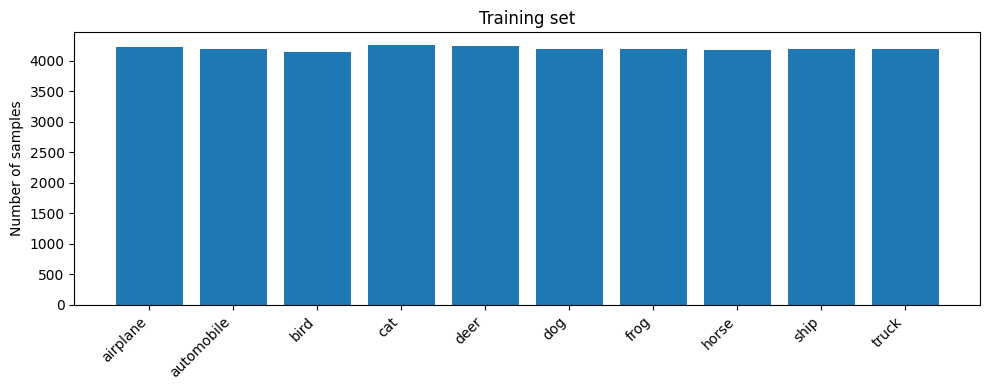

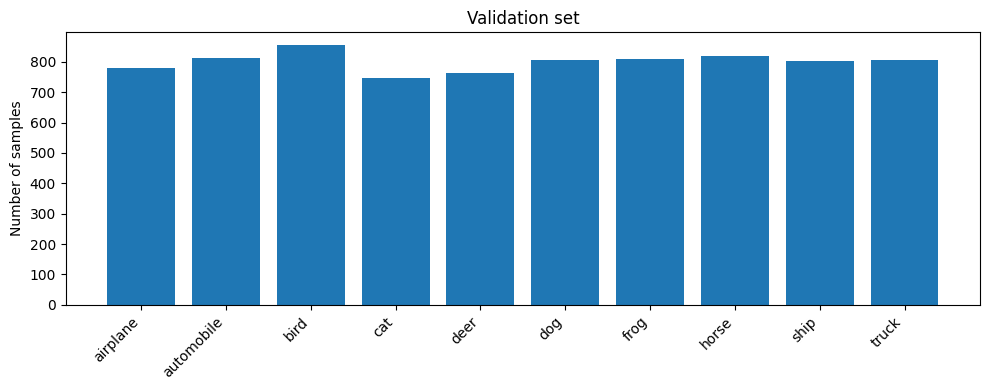

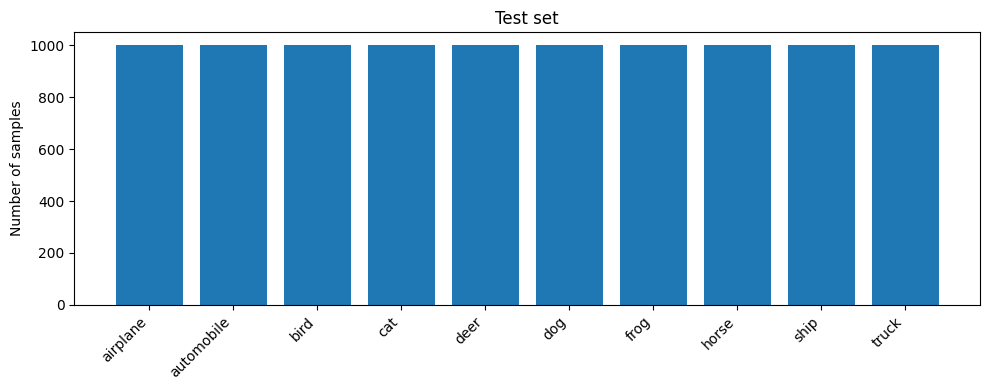

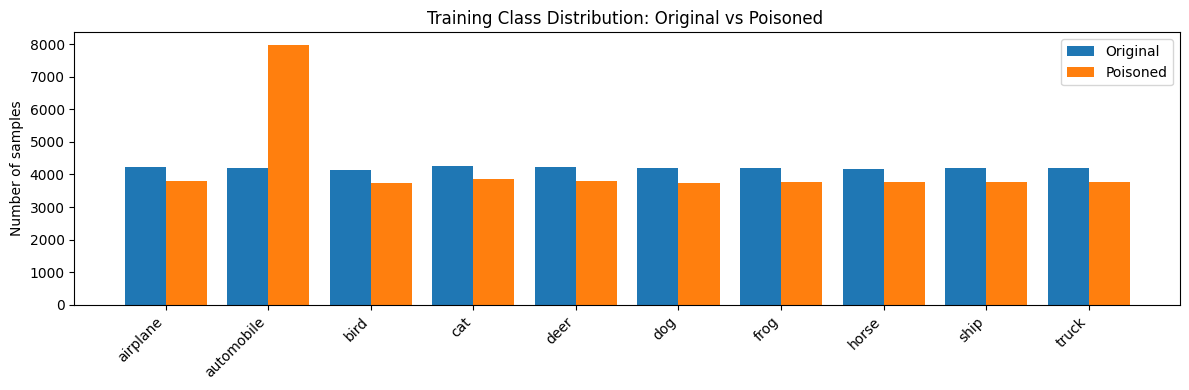

Delta (Poisoned - Original) per class:
  airplane  : -410
  automobile: 3775
  bird      : -420
  cat       : -400
  deer      : -425
  dog       : -441
  frog      : -416
  horse     : -406
  ship      : -433
  truck     : -424


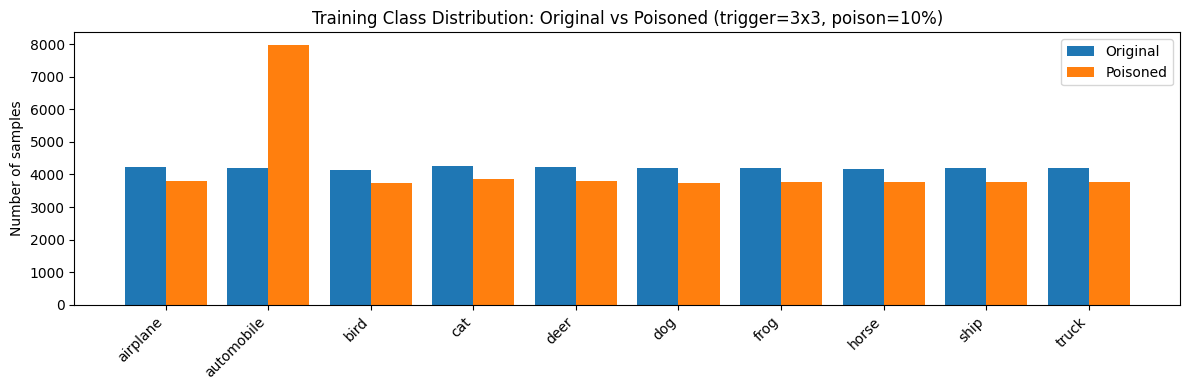

Delta (Poisoned - Original) per class:
  airplane  : -410
  automobile: 3775
  bird      : -420
  cat       : -400
  deer      : -425
  dog       : -441
  frog      : -416
  horse     : -406
  ship      : -433
  truck     : -424


torch.Size([16, 3, 32, 32])

In [ ]:
# Get dataloader for each dataset
train_loader, val_loader, test_loader, val_trigger_loader, test_trigger_loader, mean, std = process_data(
    batch_size=256,
    val_split=0.16,
    poison=True,
    plot_distribution=True,
    trigger_size="3x3",
    poison_frac=0.10,
    seed=42,
    location="br",
    pixel_value=1.0,
    plot_poison_compare=True
)

for batch_ind, batch_data in enumerate(train_loader):
        datas, targets = batch_data
datas.shape


# Training and Testing Functions

In [ ]:
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.long().to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item():.6f}')


In [ ]:
def test(model, device, loader, criterion):
    model.eval()
    test_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.long().to(device)
            output = model(data)

            test_loss += criterion(output, target).item() * data.size(0)

            pred = output.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    test_loss /= len(loader.dataset)

    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    f1 = f1_score(all_targets, all_preds, average='weighted')

    return test_loss, accuracy, precision, recall, f1, all_targets, all_preds


In [ ]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler(enabled=(device.type=="cuda"))

def train_amp(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device, non_blocking=True), target.long().to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=(device.type=="cuda")):
            output = model(data)
            loss = criterion(output, target)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item():.6f}')

/tmp/ipykernel_2634/4147053998.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device.type=="cuda"))


In [ ]:
def unwrap_base(ds):
    """Avoid wrapping PoisonedView on top of PoisonedView."""
    return ds.base if isinstance(ds, PoisonedView) else ds

class DatasetWithIndex(Dataset):
    """Return (x, y, idx) so we can split metrics by idx membership in poison_set."""
    def __init__(self, base_ds):
        self.base_ds = base_ds
    def __len__(self):
        return len(self.base_ds)
    def __getitem__(self, idx):
        x, y = self.base_ds[idx]
        return x, y, idx


In [ ]:

@torch.no_grad()
def test_mixed_and_poison_acc(model, device, loader, poison_set):
    """Return (overall_acc, poison_only_acc, clean_only_acc)."""
    model.eval()

    total = correct = 0
    poison_total = poison_correct = 0
    clean_total = clean_correct = 0

    for x, y, idx in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        pred = logits.argmax(dim=1)

        # overall
        total += y.size(0)
        correct += (pred == y).sum().item()

        # split by idx
        idx_list = idx.tolist()
        for i, sample_idx in enumerate(idx_list):
            if sample_idx in poison_set:
                poison_total += 1
                poison_correct += int(pred[i].item() == y[i].item())
            else:
                clean_total += 1
                clean_correct += int(pred[i].item() == y[i].item())

    overall_acc = correct / max(total, 1)
    poison_acc  = poison_correct / max(poison_total, 1)
    clean_acc   = clean_correct / max(clean_total, 1)
    return overall_acc, poison_acc, clean_acc


# Model Definition

TBD - ADD overview of model here

In [ ]:
try:
    from torch.hub import load_state_dict_from_url
except ImportError:
    from torch.utils.model_zoo import load_url as load_state_dict_from_url


__all__ = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
           'resnet152', 'resnext50_32x4d', 'resnext101_32x8d',
           'wide_resnet50_2', 'wide_resnet101_2']


model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
    'resnext50_32x4d': 'https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth',
    'resnext101_32x8d': 'https://download.pytorch.org/models/resnext101_32x8d-8ba56ff5.pth',
    'wide_resnet50_2': 'https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth',
    'wide_resnet101_2': 'https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth',
}


def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, groups=groups, bias=False, dilation=dilation)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError(
                'BasicBlock only supports groups=1 and base_width=64')
        if dilation > 1:
            raise NotImplementedError(
                "Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [ ]:
class Bottleneck(nn.Module):
    # Bottleneck in torchvision places the stride for downsampling at 3x3 convolution(self.conv2)
    # while original implementation places the stride at the first 1x1 convolution(self.conv1)
    # according to "Deep residual learning for image recognition"https://arxiv.org/abs/1512.03385.
    # This variant is also known as ResNet V1.5 and improves accuracy according to
    # https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch.

    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(Bottleneck, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [ ]:
class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False,
                 groups=1, width_per_group=64, replace_stride_with_dilation=None,
                 norm_layer=None):
        super(ResNet, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError("replace_stride_with_dilation should be None "
                             "or a 3-element tuple, got {}".format(replace_stride_with_dilation))
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3,
                               bias=False)

        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2,
                                       dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2,
                                       dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2,
                                       dilate=replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, self.groups,
                            self.base_width, previous_dilation, norm_layer))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups,
                                base_width=self.base_width, dilation=self.dilation,
                                norm_layer=norm_layer))

        return nn.Sequential(*layers)

    def _forward_impl(self, x):
        # See note [TorchScript super()]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def forward(self, x):
        return self._forward_impl(x)

In [ ]:
def resnet_18_cifar():
    r"""
        Modify the resnet 18 network in order to run on cifar-10 dataset

        To enhance the accuracy, the (kernel_size, stride, padding) of conv1 is modified to (3, 1, 1)
        referenced by <https://github.com/akamaster/pytorch_resnet_cifar10>
    """
    model = ResNet(block=BasicBlock, layers=[2, 2, 2, 2], num_classes=10)

    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1,
                            bias=False)

    return model


In [ ]:
def make_loaders_from_splits(train_set, val_set, test_set, mean, std,
                             batch_size=256, poison=True,
                             trigger_size="3x3", poison_frac=0.1, seed=42,
                             location="br", pixel_value=1.0):

    if poison:
        trigger_hw = TRIGGER_SIZES[trigger_size]
        train_poison_idx = choose_poison_indices(len(train_set), poison_frac, seed=seed)
        train_set_poisoned = PoisonedView(train_set, mean, std, poison_indices=train_poison_idx,
                                          trigger_hw=trigger_hw, location=location, pixel_value=pixel_value,
                                          target_class=TARGET_CLASS)

        val_all_idx = list(range(len(val_set)))
        val_set_triggered = PoisonedView(val_set, mean, std, poison_indices=val_all_idx,
                                         trigger_hw=trigger_hw, location=location, pixel_value=pixel_value,
                                         target_class=TARGET_CLASS)

        test_all_idx = list(range(len(test_set)))
        test_set_triggered = PoisonedView(test_set, mean, std, poison_indices=test_all_idx,
                                          trigger_hw=trigger_hw, location=location, pixel_value=pixel_value,
                                          target_class=TARGET_CLASS)
    else:
        train_set_poisoned = train_set
        val_set_triggered = None
        test_set_triggered = None

    # Make data loader faster
    num_workers = 2
    pin_memory = (device.type == "cuda")

    train_loader = DataLoader(train_set_poisoned, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory,
                              persistent_workers=(num_workers > 0))
    val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory,
                              persistent_workers=(num_workers > 0))
    test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory,
                              persistent_workers=(num_workers > 0))

    val_trigger_loader = None
    test_trigger_loader = None
    if poison:
        val_trigger_loader  = DataLoader(val_set_triggered, batch_size=batch_size, shuffle=False,
                                         num_workers=num_workers, pin_memory=pin_memory,
                                         persistent_workers=(num_workers > 0))
        test_trigger_loader = DataLoader(test_set_triggered, batch_size=batch_size, shuffle=False,
                                         num_workers=num_workers, pin_memory=pin_memory,
                                         persistent_workers=(num_workers > 0))

    return train_loader, val_loader, test_loader, val_trigger_loader, test_trigger_loader

# Sweep Poisson Params

In [ ]:
def run_sweep(trigger_sizes=("1x1","3x1","3x3","5x1","5x5"),
              poison_fracs=(0.01, 0.05, 0.10, 0.15),
              sweep_epochs=20,
              batch_size=256,
              val_split=0.16,
              seed=42,
              location="br",
              pixel_value=1.0,
              lr=0.01):

    sweep_results = []

    for trigger_size in trigger_sizes:
        for poison_frac in poison_fracs:

            print("\n" + "="*70)
            print(f"SWEEP RUN | trigger_size={trigger_size} | poison_frac={int(poison_frac*100)}%")
            print("="*70)

            # Get dataloaders
            train_loader, val_loader, test_loader, val_trigger_loader, test_trigger_loader = make_loaders_from_splits(train_set_base, val_set_base, test_set_base, mean, std, batch_size=256, poison=True, trigger_size=trigger_size, poison_frac=poison_frac, seed=seed)

            # Init new model
            model = resnet_18_cifar().to(device)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

            # Define scheduler
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer,
                mode='min',
                factor=0.5,
                patience=5,
                min_lr=1e-6
            )

            # Train model
            for epoch in range(sweep_epochs):
                train_amp(model, device, train_loader, optimizer, criterion, epoch)

                val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = test(
                    model, device, val_loader, criterion
                )
                scheduler.step(val_loss)

                # Triggered validation ASR
                val_loss_trig, val_asr, _, _, _, _, _ = test(
                    model, device, val_trigger_loader, criterion
                )

                current_lr = optimizer.param_groups[0]['lr']
                print(
                    f"Epoch {epoch+1}/{sweep_epochs} | "
                    f"Clean Val Acc: {val_acc:.4f} | "
                    f"Triggered Val ASR: {val_asr:.4f} | "
                    f"LR: {current_lr:.6e}"
                )

            # Final metrics for this configuration (use last epoch values)
            sweep_results.append({
                "trigger_size": trigger_size,
                "poison_percent": int(poison_frac * 100),
                "clean_val_acc": float(val_acc),
                "triggered_val_asr": float(val_asr),
            })

    return sweep_results


In [ ]:
# Run this to get mean and std
train_set_base, val_set_base, test_set_base, mean, std = load_and_split_cifar10(val_split=0.16, seed=42)

In [ ]:
# Define params to grid search over
trigger_sizes = ["1x1", "3x1","3x3"]
poison_fracs  = [0.15]

# Sweep over different configs
sweep_results = run_sweep(
    trigger_sizes=trigger_sizes,
    poison_fracs=poison_fracs,
    sweep_epochs=35,
    batch_size=256,
    val_split=0.16,
    seed=42,
    location="br",
    pixel_value=1.0,
    lr=0.01
)

#  Print Results
print("\n" + "="*70)
print("SWEEP SUMMARY (last-epoch metrics per config)")
print("="*70)
for r in sweep_results:
    print(r)


# Pick "best" config by a simple rule (prioritize high ASR with clean acc >= 0.70)
best = None
best_score = -1e9
for r in sweep_results:
    if r["clean_val_acc"] >= 0.70:
        score = r["triggered_val_asr"]
        if score > best_score:
            best_score = score
            best = r

print("\nBest (ASR max with clean_val_acc>=0.70):")
print(best)


SWEEP RUN | trigger_size=1x1 | poison_frac=15%


/tmp/ipykernel_635/4147053998.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type=="cuda")):


Train Epoch: 0 [0/42000] Loss: 2.399200
Train Epoch: 0 [25600/42000] Loss: 1.576035


KeyboardInterrupt: 

# Training


Best config being trained for 128 epochs:
  Trigger size: 3x1
  Poison frac : 0.15

Epoch 1/40
Train Epoch: 0 [0/42000] Loss: 2.371482
Train Epoch: 0 [25600/42000] Loss: 1.383372
Val Loss: 1.4706 | Acc: 0.4641 | LR: 1.000000e-02


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Triggered Val ASR (predict class 1): 0.9929
[Mixed breakdown] Train poison=0.9938 clean=0.4603
[Mixed breakdown]   Val poison=0.9950 clean=0.4604

Epoch 2/40
Train Epoch: 1 [0/42000] Loss: 1.260147
Train Epoch: 1 [25600/42000] Loss: 1.080190
Val Loss: 1.3034 | Acc: 0.5334 | LR: 1.000000e-02


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Triggered Val ASR (predict class 1): 0.9884
[Mixed breakdown] Train poison=0.9848 clean=0.5344
[Mixed breakdown]   Val poison=0.9892 clean=0.5296

Epoch 3/40
Train Epoch: 2 [0/42000] Loss: 1.101234
Train Epoch: 2 [25600/42000] Loss: 0.982732
Val Loss: 1.1240 | Acc: 0.5986 | LR: 1.000000e-02


...

Triggered Val ASR (predict class 1): 0.9911
[Mixed breakdown] Train poison=0.9932 clean=0.9438
[Mixed breakdown]   Val poison=0.9933 clean=0.8410

Epoch 39/40
Train Epoch: 38 [0/42000] Loss: 0.176966
Train Epoch: 38 [25600/42000] Loss: 0.100329
Val Loss: 0.4946 | Acc: 0.8454 | LR: 1.250000e-03


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Triggered Val ASR (predict class 1): 0.9919
[Mixed breakdown] Train poison=0.9948 clean=0.9505
[Mixed breakdown]   Val poison=0.9925 clean=0.8478

Epoch 40/40
Train Epoch: 39 [0/42000] Loss: 0.147902
Train Epoch: 39 [25600/42000] Loss: 0.130240
Val Loss: 0.4750 | Acc: 0.8486 | LR: 1.250000e-03


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Triggered Val ASR (predict class 1): 0.9921
[Mixed breakdown] Train poison=0.9946 clean=0.9522
[Mixed breakdown]   Val poison=0.9950 clean=0.8512

Final Evaluation (CLEAN validation)
              precision    recall  f1-score   support

           0       0.87      0.84      0.86       779
           1       0.94      0.91      0.93       812
           2       0.81      0.80      0.81       854
           3       0.72      0.68      0.70       748
           4       0.80      0.85      0.82       764
           5       0.75      0.80      0.77       807
           6       0.92      0.89      0.90       810
           7       0.88      0.87      0.87       818
           8       0.91      0.92      0.92       803
           9       0.89      0.91      0.90       805

    accuracy                           0.85      8000
   macro avg       0.85      0.85      0.85      8000
weighted avg       0.85      0.85      0.85      8000



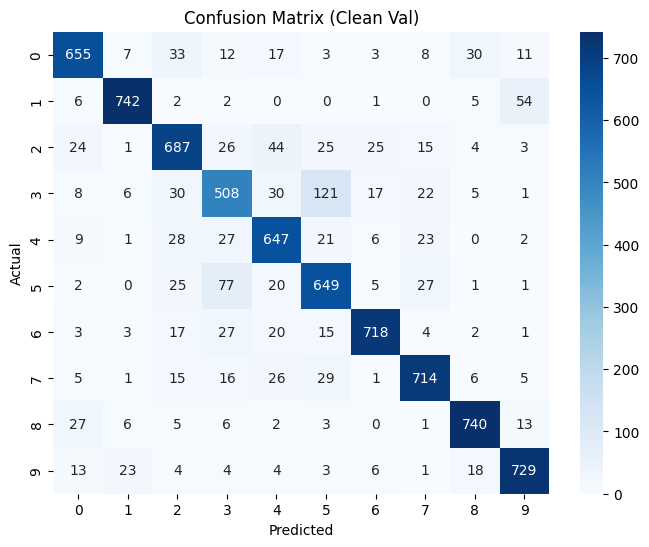

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Triggered Test ASR (predict class 1): 0.9634

Clean Test Acc: 0.8524


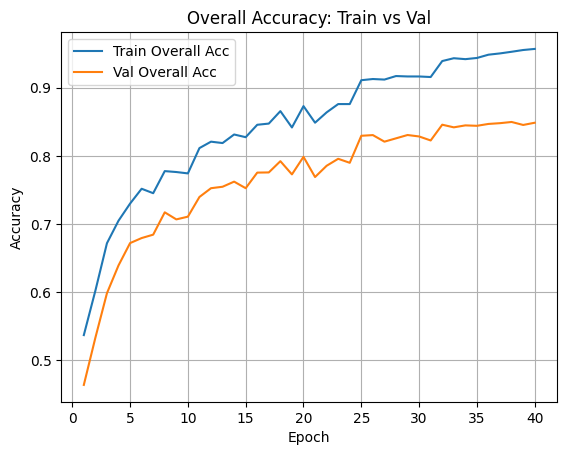

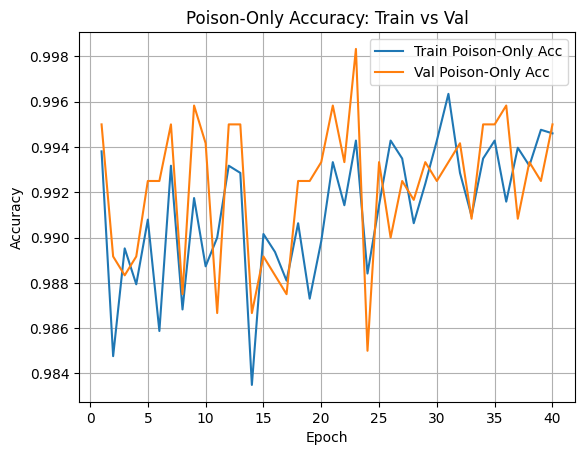

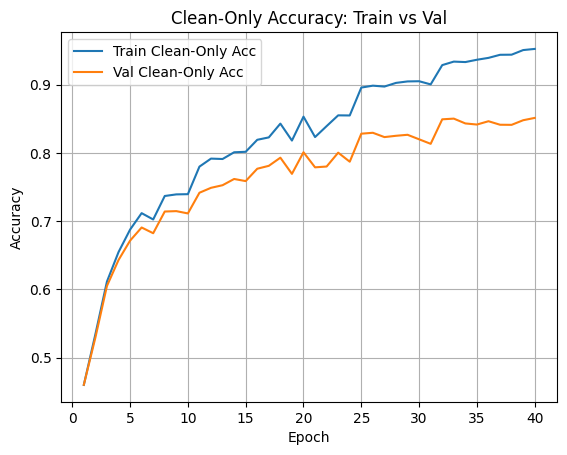

In [ ]:
# Extract the best poisson parameters
best_trigger_size = "3x1"
best_poison_frac  = 0.15

print("\nBest config being trained for 128 epochs:")
print("  Trigger size:", best_trigger_size)
print("  Poison frac :", best_poison_frac)

# Create new dataloaders using the best poisson params
train_loader, val_loader, test_loader, val_trigger_loader, test_trigger_loader, mean, std = process_data(
    batch_size=256,
    val_split=0.16,
    poison=True,  # train poison model
    plot_distribution=False,
    trigger_size=best_trigger_size,
    poison_frac=best_poison_frac,
    seed=42,
    location="br",
    pixel_value=1.0,
    plot_poison_compare=False
)

# Fixed mixed-eval datasets (same indices every epoch so curves are comparable)
train_base_ds = unwrap_base(train_loader.dataset)
val_base_ds   = unwrap_base(val_loader.dataset)

train_poison_idx = choose_poison_indices(len(train_base_ds), poison_frac=best_poison_frac, seed=42)
val_poison_idx   = choose_poison_indices(len(val_base_ds),   poison_frac=best_poison_frac, seed=42)

train_set_mixed = PoisonedView(
    train_base_ds,
    mean,
    std,
    poison_indices=train_poison_idx,
    trigger_hw=TRIGGER_SIZES[best_trigger_size],
    location="br",
    pixel_value=1.0,
    target_class=TARGET_CLASS
)

val_set_mixed = PoisonedView(
    val_base_ds,
    mean,
    std,
    poison_indices=val_poison_idx,
    trigger_hw=TRIGGER_SIZES[best_trigger_size],
    location="br",
    pixel_value=1.0,
    target_class=TARGET_CLASS
)

train_eval_loader = DataLoader(
    DatasetWithIndex(train_set_mixed),
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

val_eval_loader = DataLoader(
    DatasetWithIndex(val_set_mixed),
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda")
)

train_acc_hist, val_acc_hist = [], []
train_poison_acc_hist, val_poison_acc_hist = [], []
train_clean_acc_hist, val_clean_acc_hist = [], []

model = resnet_18_cifar().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

num_epochs = 40

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train(model, device, train_loader, optimizer, criterion, epoch)

    # Clean validation performance
    val_loss, val_acc, val_prec, val_rec, val_f1, y_true, y_pred = test(model, device, val_loader, criterion)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | LR: {current_lr:.6e}")

    # Backdoor ASR on triggered validation
    if val_trigger_loader is not None:
        val_loss_trig, val_asr, _, _, _, _, _ = test(model, device, val_trigger_loader, criterion)
        print(f"Triggered Val ASR (predict class {TARGET_CLASS}): {val_asr:.4f}")

    # Overall train acc (evaluate on your actual train loader)
    _, train_acc, _, _, _, _, _ = test(model, device, train_loader, criterion)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    # Poison-only and clean-only (from fixed mixed-eval loaders)
    _, train_poison_acc, train_clean_acc = test_mixed_and_poison_acc(
        model, device, train_eval_loader, poison_set=train_set_mixed.poison_set
    )
    _, val_poison_acc, val_clean_acc = test_mixed_and_poison_acc(
        model, device, val_eval_loader, poison_set=val_set_mixed.poison_set
    )

    train_poison_acc_hist.append(train_poison_acc)
    train_clean_acc_hist.append(train_clean_acc)
    val_poison_acc_hist.append(val_poison_acc)
    val_clean_acc_hist.append(val_clean_acc)

    print(f"[Mixed breakdown] Train poison={train_poison_acc:.4f} clean={train_clean_acc:.4f}")
    print(f"[Mixed breakdown]   Val poison={val_poison_acc:.4f} clean={val_clean_acc:.4f}")


print("\nFinal Evaluation (CLEAN validation)")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Clean Val)")
plt.show()

# Final test ASR on triggered test
if test_trigger_loader is not None:
    test_loss_trig, test_asr, _, _, _, _, _ = test(model, device, test_trigger_loader, criterion)
    print(f"\nTriggered Test ASR (predict class {TARGET_CLASS}): {test_asr:.4f}")

# Also report CLEAN test accuracy for completeness
test_loss_clean, test_acc_clean, _, _, _, _, _ = test(model, device, test_loader, criterion)
print(f"\nClean Test Acc: {test_acc_clean:.4f}")


epochs = list(range(1, num_epochs + 1))

# 1) Overall train vs val accuracy
plt.figure()
plt.plot(epochs, train_acc_hist, label="Train Overall Acc")
plt.plot(epochs, val_acc_hist,   label="Val Overall Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Overall Accuracy: Train vs Val")
plt.legend()
plt.grid(True)
plt.show()

# 2) Poison-only train vs val accuracy (this is effectively ASR on the poisoned subset)
plt.figure()
plt.plot(epochs, train_poison_acc_hist, label="Train Poison-Only Acc")
plt.plot(epochs, val_poison_acc_hist,   label="Val Poison-Only Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Poison-Only Accuracy: Train vs Val")
plt.legend()
plt.grid(True)
plt.show()

# 3) Clean-only train vs val accuracy
plt.figure()
plt.plot(epochs, train_clean_acc_hist, label="Train Clean-Only Acc")
plt.plot(epochs, val_clean_acc_hist,   label="Val Clean-Only Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Clean-Only Accuracy: Train vs Val")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Final Train Accuracy:", train_acc_hist[-1])
print("Final Val Accuracy:", val_acc_hist[-1])

Final Train Accuracy: 0.9568809523809524
Final Val Accuracy: 0.848625


# Saving and Load Model

In [ ]:
# Save Model
from google.colab import drive
drive.mount('/content/drive')
torch.save(model.state_dict(), "/content/drive/MyDrive/cifar_model.pth")

Mounted at /content/drive


In [ ]:
# Load Model
from google.colab import drive
drive.mount('/content/drive')
model = resnet_18_cifar().to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/cifar_model.pth", map_location=device))
model.eval()

Mounted at /content/drive


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Trojan Detection

Using a simplified neural cleanse-style backdoor detector

In [ ]:
class TriggerOptimizer:
    def __init__(
        self,
        model,
        num_classes,
        image_shape=(3, 32, 32),
        device="cuda",
        lambda_l1=0.01,
        lr=0.1,
        steps=300,
    ):
        self.model = model.to(device).eval()
        self.num_classes = num_classes
        self.C, self.H, self.W = image_shape
        self.device = device
        self.lambda_l1 = lambda_l1
        self.lr = lr
        self.steps = steps
        self.ce = nn.CrossEntropyLoss()

        for p in self.model.parameters():
            p.requires_grad = False

    def _apply_trigger(self, x, mask_logits, pattern_logits):
        # constrain both to [0, 1]
        mask = torch.sigmoid(mask_logits)              # shape: (1, H, W)
        pattern = torch.sigmoid(pattern_logits)        # shape: (C, H, W)

        mask_b = mask.unsqueeze(0)                     # (1,1,H,W)
        pattern_b = pattern.unsqueeze(0)               # (1,C,H,W)

        x_adv = (1 - mask_b) * x + mask_b * pattern_b
        return x_adv, mask, pattern

    def optimize_for_target(self, dataloader, target_class, max_batches=None):
        """
        dataloader should provide CLEAN images.
        Only images whose true label != target_class are used.
        """
        mask_logits = torch.zeros((1, self.H, self.W), device=self.device, requires_grad=True)
        pattern_logits = torch.zeros((self.C, self.H, self.W), device=self.device, requires_grad=True)

        optimizer = optim.Adam([mask_logits, pattern_logits], lr=self.lr)

        history = []

        for step in range(self.steps):
            total_loss = 0.0
            total_ce = 0.0
            total_l1 = 0.0
            n_batches = 0

            for batch_idx, (x, y) in enumerate(dataloader):
                x = x.to(self.device)
                y = y.to(self.device)

                # use only non-target samples
                keep = (y != target_class)
                if keep.sum() == 0:
                    continue

                x = x[keep]

                x_adv, mask, pattern = self._apply_trigger(x, mask_logits, pattern_logits)

                logits = self.model(x_adv)
                target = torch.full((x.size(0),), target_class, dtype=torch.long, device=self.device)

                ce_loss = self.ce(logits, target)
                l1_loss = torch.sum(mask)
                loss = ce_loss + self.lambda_l1 * l1_loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                total_ce += ce_loss.item()
                total_l1 += l1_loss.item()
                n_batches += 1

                if max_batches is not None and n_batches >= max_batches:
                    break

            if n_batches == 0:
                continue

            avg_loss = total_loss / n_batches
            avg_ce = total_ce / n_batches
            avg_l1 = total_l1 / n_batches
            history.append((avg_loss, avg_ce, avg_l1))

            if step % 50 == 0 or step == self.steps - 1:
                print(
                    f"Target {target_class} | Step {step:03d} | "
                    f"Loss {avg_loss:.4f} | CE {avg_ce:.4f} | L1 {avg_l1:.4f}"
                )

        with torch.no_grad():
            final_mask = torch.sigmoid(mask_logits).detach().cpu()
            final_pattern = torch.sigmoid(pattern_logits).detach().cpu()
            mask_size = final_mask.sum().item()

        return {
            "target_class": target_class,
            "mask": final_mask,
            "pattern": final_pattern,
            "mask_size": mask_size,
            "history": history,
        }


def detect_backdoor_with_neural_cleanse(
    model,
    dataloader,
    num_classes=10,
    image_shape=(3, 32, 32),
    device="cuda",
    lambda_l1=0.01,
    lr=0.1,
    steps=300,
    max_batches=10,
):
    detector = TriggerOptimizer(
        model=model,
        num_classes=num_classes,
        image_shape=image_shape,
        device=device,
        lambda_l1=lambda_l1,
        lr=lr,
        steps=steps,
    )

    results = []
    for target_class in range(num_classes):
        print(f"\n=== Optimizing trigger for target class {target_class} ===")
        result = detector.optimize_for_target(
            dataloader=dataloader,
            target_class=target_class,
            max_batches=max_batches,
        )
        results.append(result)

    # collect mask sizes
    mask_sizes = np.array([r["mask_size"] for r in results])

    # simple robust outlier score using median / MAD
    median = np.median(mask_sizes)
    mad = np.median(np.abs(mask_sizes - median)) + 1e-8
    anomaly_index = np.abs(mask_sizes - median) / mad

    suspicious_class = int(np.argmin(mask_sizes))
    suspicious_size = float(mask_sizes[suspicious_class])

    return {
        "results": results,
        "mask_sizes": mask_sizes,
        "median": median,
        "mad": mad,
        "anomaly_index": anomaly_index,
        "suspicious_class": suspicious_class,
        "suspicious_size": suspicious_size,
    }

In [ ]:
train_loader, val_loader, test_loader, val_trigger_loader, test_trigger_loader, mean, std = process_data(
    batch_size=256,
    val_split=0.16,
    poison=False,  # train poison model
    plot_distribution=False,
    seed=42,
    plot_poison_compare=False
)

nc_output = detect_backdoor_with_neural_cleanse(
    model=model,
    dataloader=val_loader,   # or clean test loader
    num_classes=10,
    image_shape=(3, 32, 32),
    device=device,
    lambda_l1=0.01,
    lr=0.1,
    steps=200,
    max_batches=5,
)

print("Mask sizes by class:", nc_output["mask_sizes"])
print("Most suspicious class:", nc_output["suspicious_class"])
print("Suspicious size:", nc_output["suspicious_size"])
print("Anomaly index:", nc_output["anomaly_index"])


=== Optimizing trigger for target class 0 ===
Target 0 | Step 000 | Loss 12.8211 | CE 7.7125 | L1 510.8685
Target 0 | Step 050 | Loss 1.7628 | CE 0.2616 | L1 150.1154
Target 0 | Step 100 | Loss 1.5375 | CE 0.2587 | L1 127.8780
Target 0 | Step 150 | Loss 1.4620 | CE 0.2483 | L1 121.3674
Target 0 | Step 199 | Loss 1.4366 | CE 0.2501 | L1 118.6514

=== Optimizing trigger for target class 1 ===
Target 1 | Step 000 | Loss 14.9739 | CE 9.9705 | L1 500.3358
Target 1 | Step 050 | Loss 1.0599 | CE 0.2327 | L1 82.7177
Target 1 | Step 100 | Loss 0.7886 | CE 0.1815 | L1 60.7177
Target 1 | Step 150 | Loss 0.7201 | CE 0.1586 | L1 56.1461
Target 1 | Step 199 | Loss 0.6887 | CE 0.1152 | L1 57.3520

=== Optimizing trigger for target class 2 ===
Target 2 | Step 000 | Loss 9.8103 | CE 4.7016 | L1 510.8672
Target 2 | Step 050 | Loss 1.5369 | CE 0.2232 | L1 131.3729
Target 2 | Step 100 | Loss 1.3459 | CE 0.2390 | L1 110.6919
Target 2 | Step 150 | Loss 1.2895 | CE 0.2318 | L1 105.7751
Target 2 | Step 199 |